## Diabetes Prediction
Dataset link : https://www.kaggle.com/datasets/johndasilva/diabetes

In [45]:
#importing essential libraries
import numpy as np
import pandas as pd

In [46]:
#loading Datasets
df = pd.read_csv('datasets/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


### Exploring datasets

In [47]:
df.shape #return the no of column and rows in the dataset

(2000, 9)

In [48]:
df.columns #return the name of columns in the dataset

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [49]:
df.dtypes #return the data type of each column in the dataset

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [50]:
df.info() #return the summary of the dataset /basic information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [51]:
df.describe() #return the statistical summary of the dataset / basics statistics about the dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [52]:
df.describe().T    #return the statistical summary of the dataset

,count,mean,std,min,25%,50%,75%,max
Pregnancies,2000.0,3.70350,3.306063,0.000,1.000,3.000,6.000,17.00
Glucose,2000.0,121.18250,32.068636,0.000,99.000,117.000,141.000,199.00
BloodPressure,2000.0,69.14550,19.188315,0.000,63.500,72.000,80.000,122.00
SkinThickness,2000.0,20.93500,16.103243,0.000,0.000,23.000,32.000,110.00
Insulin,2000.0,80.25400,111.180534,0.000,0.000,40.000,130.000,744.00
BMI,2000.0,32.19300,8.149901,0.000,27.375,32.300,36.800,80.60
DiabetesPedigreeFunction,2000.0,0.47093,0.323553,0.078,0.244,0.376,0.624,2.42
Age,2000.0,33.09050,11.786423,21.000,24.000,29.000,40.000,81.00
Outcome,2000.0,0.34200,0.474498,0.000,0.000,0.000,1.000,1.00


In [53]:
df.isnull().sum() #return the number of missing values in each column of the dataset

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [54]:
df.isnull().any() #return true if there is any missing value in the dataset otherwise return false

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

In [55]:
df = df.rename(columns={'DiabetesPedigreeFunction':'DPF'})
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

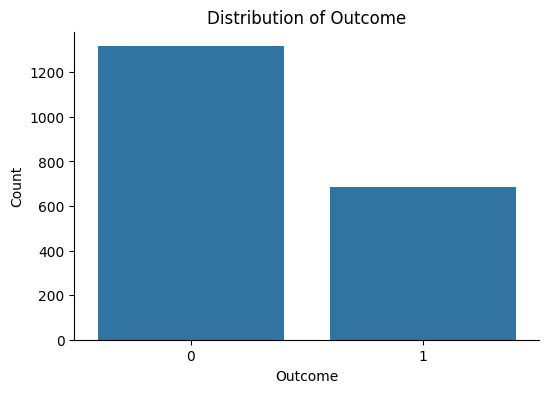

In [57]:
#plotting the outcome based on the number of dataser entries
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome',data=df) #return the count of each class in the target variable

plt.gca().spines['top'].set_visible(False) #remove the top border of the plot
plt.gca().spines['right'].set_visible(False) #remove the right border of the plot
plt.title('Distribution of Outcome') #set the title of the plot
plt.xlabel('Outcome') #set the label of x-axis
plt.ylabel('Count') #set the label of y-axis
plt.show() #display the plot    

### Data Cleaning

In [58]:
df_copy = df.copy(deep=True) #create a copy of the original dataset
 #replace the zero values with NaN in the specified columns
df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)
df_copy.isnull().sum() #return the number of missing values in each column of the dataset after replacing zero values with NaN

Pregnancies        0
Glucose           13
BloodPressure     90
SkinThickness    573
Insulin          956
BMI               28
DPF                0
Age                0
Outcome            0
dtype: int64

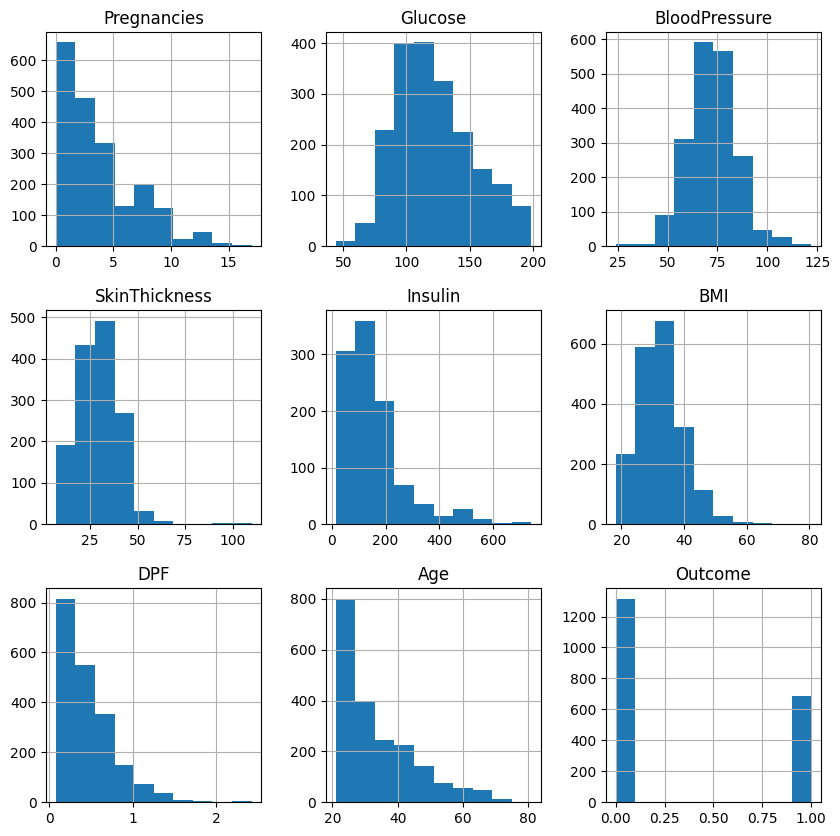

In [59]:
p = df_copy.hist(figsize=(10,10)) #plot the histogram of each column in the dataset

In [60]:
#replace the missing values nan by mean, median depending upon distribuion of the data
df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace=True) 
df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean(), inplace=True) 
df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].median(), inplace=True)
df_copy['Insulin'].fillna(df_copy['Insulin'].median(), inplace=True)
df_copy['BMI'].fillna(df_copy['BMI'].median(), inplace=True) 


/tmp/ipykernel_10980/1728138266.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace=True)
/tmp/ipykernel_10980/1728138266.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

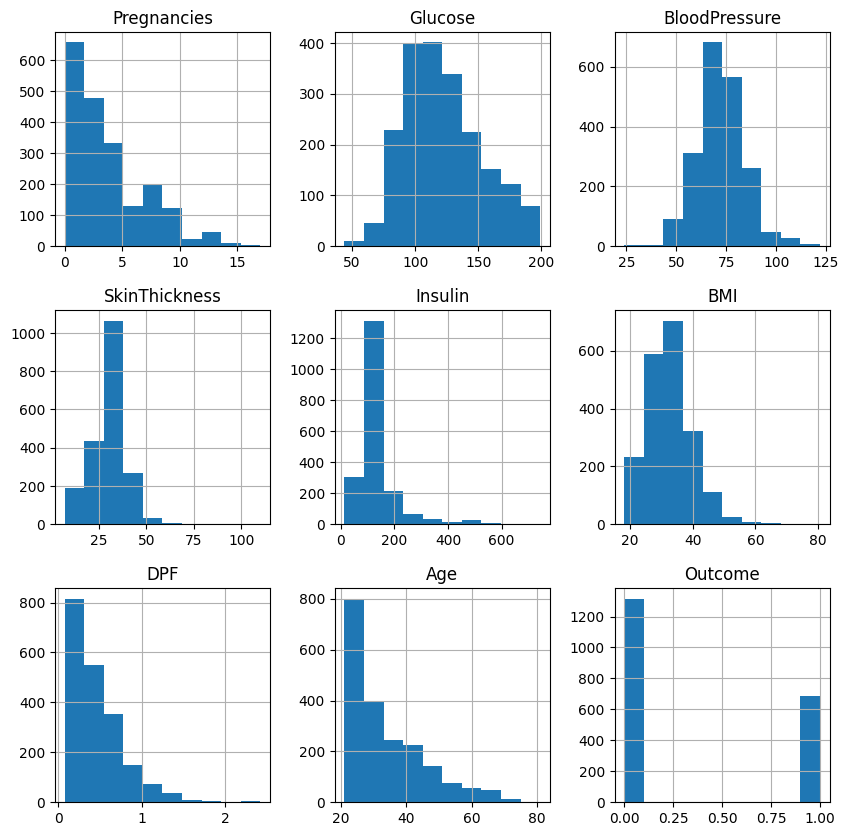

In [61]:
P = df_copy.hist(figsize=(10,10)) 

In [62]:
df_copy.isnull().sum()


Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
DPF              0
Age              0
Outcome          0
dtype: int64

## Model Building

In [70]:
import sklearn
print('sklearn version :',sklearn.__version__)
from sklearn.model_selection import train_test_split

X = df.drop(columns = 'Outcome') #separating the features and target variable
y = df['Outcome']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) #split the dataset into training and testing set
print("X_train size :{},X_test size :{},y_train size :{},y_test size :{}".format(X_train.shape,X_test.shape,y_train.shape,y_test.shape)) #return the shape of training and testing set

sklearn version : 1.7.2
X_train size :(1600, 8),X_test size :(400, 8),y_train size :(1600,),y_test size :(400,)


In [71]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #create an object of StandardScaler class
X_train_scaled = scaler.fit_transform(X_train) #fit and transform the training set
X_test_scaled = scaler.transform(X_test) #transform the testing set     


In [76]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000,C=1.0,solver='lbfgs',random_state=42) #create an object of LogisticRegression class
model.fit(X_train_scaled,y_train) #fit the model on the training set    

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'
